In [41]:
import pandas as pd
import numpy as np

### Inspection

In [42]:
df = pd.read_csv("heart_disease_uci.csv")

In [43]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [44]:
df.shape

(920, 16)

In [45]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [47]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

### Cleaning

In [48]:
df = df.drop(columns=['id','dataset'])


In [49]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [50]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [51]:
# Imputing fbs and exang with mode values
df['fbs'].fillna(df['fbs'].mode()[0], inplace=True)
df['exang'].fillna(df['exang'].mode()[0], inplace=True)

In [52]:
#Converting them to int
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

In [53]:
df[['fbs', 'exang']].head()

,fbs,exang
0,1,0
1,0,1
2,0,1
3,0,0
4,0,0


In [54]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0


In [55]:
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']

In [56]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [57]:
df['thal'].isnull().sum()

0

In [58]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [59]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150.0,0,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,0,108.0,1,1.5,3.0,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,0,129.0,1,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,0,187.0,0,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,0,172.0,0,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [60]:
df['ca'].isnull().sum()

611

In [61]:
#ca has 611 values missing, which is almost like 66% of the whole data. ca seems to be number of major blood vessels colored by fluoroscopy, which is obtained via an expensive and invasive procedure - which will be recommended only if doctor suspects heart disease. Hence, we can drop this column from the dataset.
df = df.drop(columns=['ca'])

In [62]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150.0,0,2.3,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,0,108.0,1,1.5,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,0,129.0,1,2.6,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,0,187.0,0,3.5,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,0,172.0,0,1.4,0,False,True,False,False,False,False,False,True,True,False


In [63]:
df.shape

(920, 18)

In [64]:
df.isnull().sum()

age                          0
trestbps                    59
chol                        30
fbs                          0
thalch                      55
exang                        0
oldpeak                     62
num                          0
sex_Male                     0
cp_atypical angina           0
cp_non-anginal               0
cp_typical angina            0
restecg_normal               0
restecg_st-t abnormality     0
slope_flat                   0
slope_upsloping              0
thal_normal                  0
thal_reversable defect       0
dtype: int64

In [65]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [66]:
df.isnull().sum()

age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
num                         0
sex_Male                    0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

### EDA

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df['num'].value_counts()


num
1    509
0    411
Name: count, dtype: int64

In [69]:
df['num'].value_counts(normalize=True)


num
1    0.553261
0    0.446739
Name: proportion, dtype: float64

In [70]:
pd.crosstab(df['sex_Male'], df['num'], normalize='index')


num,0,1
sex_Male,,
False,0.742268,0.257732
True,0.367769,0.632231


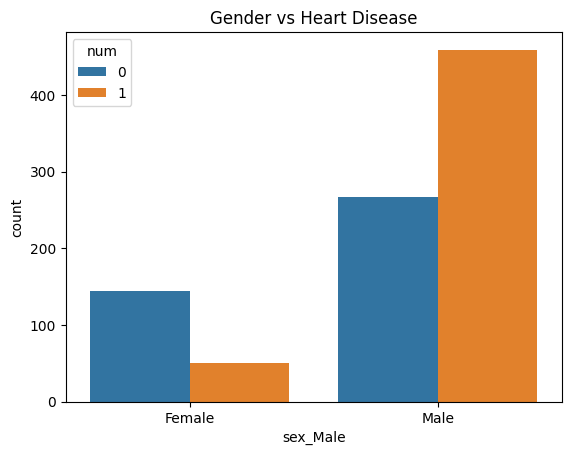

In [71]:
sns.countplot(x='sex_Male', hue='num', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Gender vs Heart Disease")
plt.show()


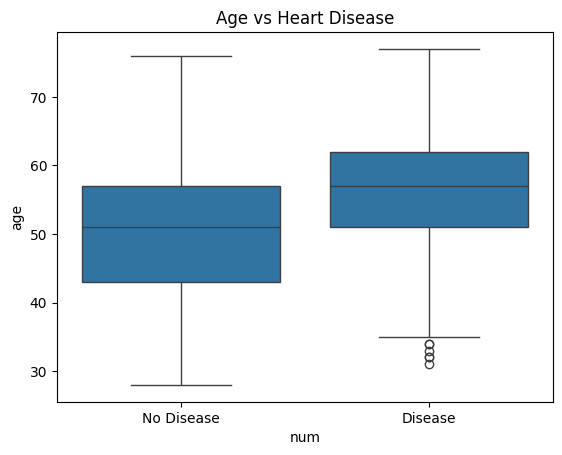

In [72]:
sns.boxplot(x='num', y='age', data=df)
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title("Age vs Heart Disease")
plt.show()


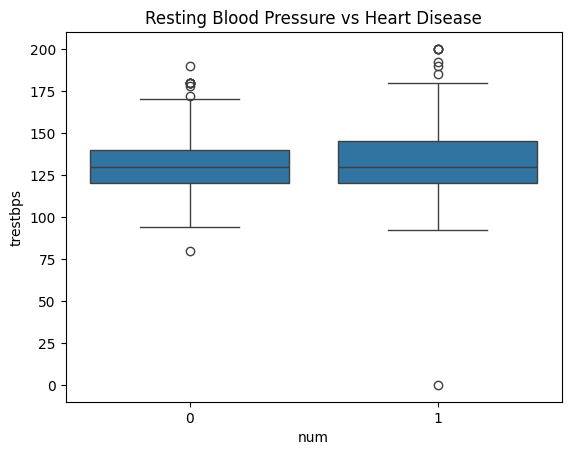

In [73]:
sns.boxplot(x='num', y='trestbps', data=df)
plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()


In [74]:
cp_cols = [col for col in df.columns if col.startswith('cp_')]
cp_cols


['cp_atypical angina', 'cp_non-anginal', 'cp_typical angina']

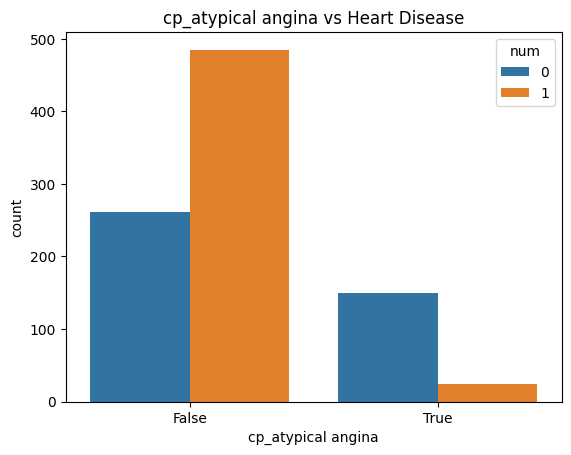

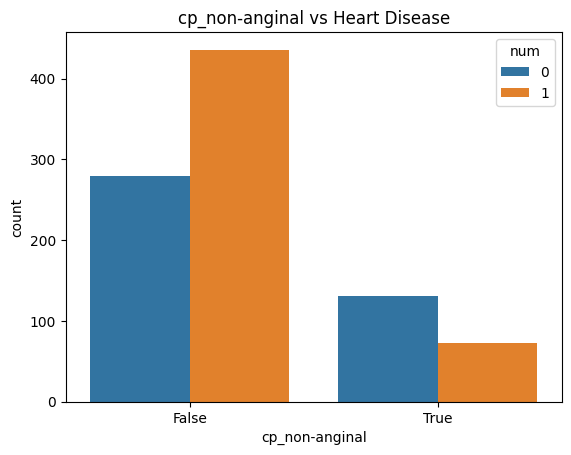

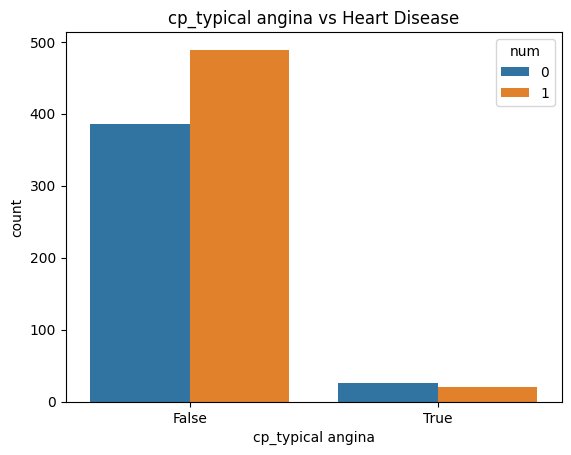

In [75]:
for col in cp_cols:
    sns.countplot(x=col, hue='num', data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()


### Correlation Analysis

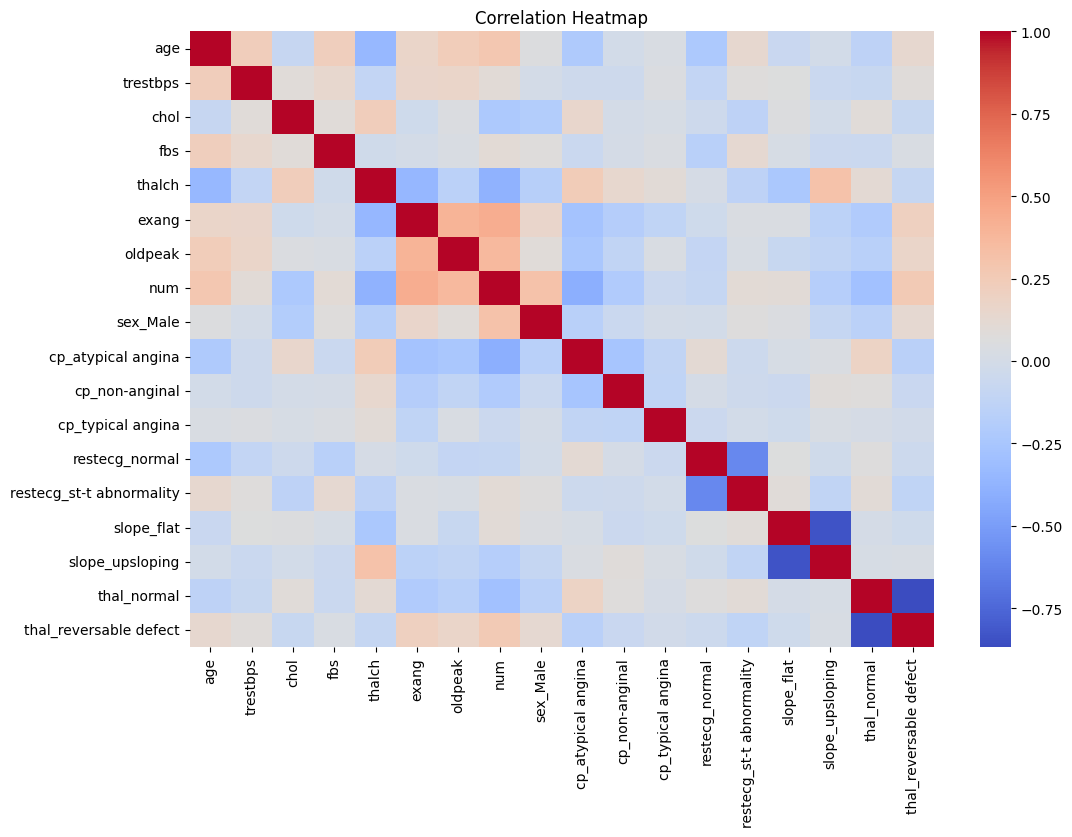

In [76]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()



In [77]:
X = df.drop(columns=['num'])
y = df['num']


In [78]:
# =========================
# 1) Train/Test Split
# =========================
from sklearn.model_selection import train_test_split

# X_selected: your feature matrix (after encoding)
# y: your target (binary)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


# =========================
# 2) Models + Evaluation
# =========================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import pandas as pd

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print("\n" + "="*60)
    print(name)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
print("\n\n=== Model Comparison (sorted by Recall) ===")
print(results_df)


Train shape: (736, 17) Test shape: (184, 17)
Train class balance:
 num
1    0.552989
0    0.447011
Name: proportion, dtype: float64
Test class balance:
 num
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Logistic Regression
Confusion Matrix:
 [[65 17]
 [13 89]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Decision Tree
Confusion Matrix:
 [[60 22]
 [19 83]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.73      0.75        82
           1       0.79      0.81      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78

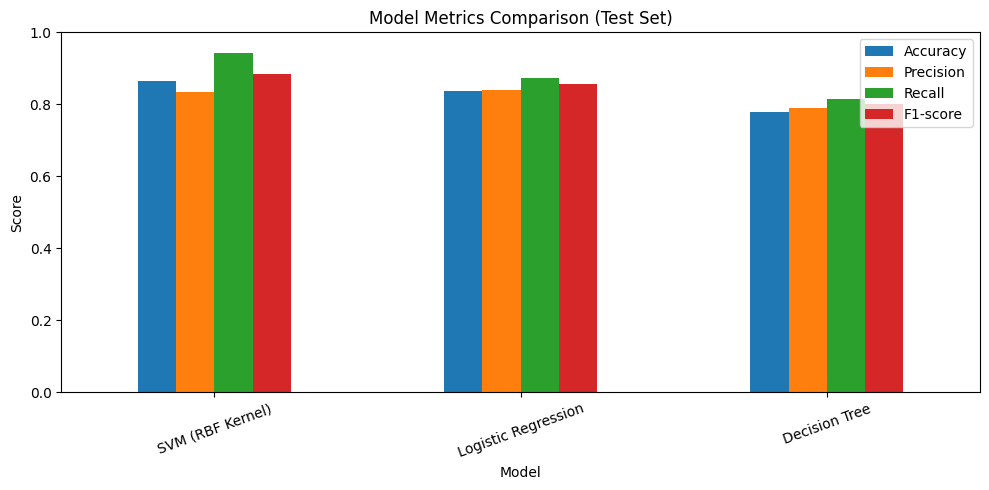

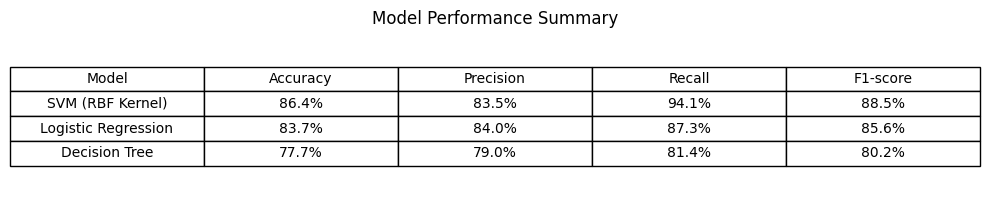

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# If you already have results_df, skip this block


# ---- Figure 1: Bar chart ----
plot_df = results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]]
ax = plot_df.plot(kind="bar", figsize=(10,5), rot=20)
plt.title("Model Metrics Comparison (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ---- Figure 2: Table figure ----
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")

table_df = results_df.copy()
for col in ["Accuracy","Precision","Recall","F1-score"]:
    table_df[col] = (table_df[col]*100).round(1).astype(str) + "%"

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.title("Model Performance Summary")
plt.tight_layout()
plt.show()
